# Solution: Hypothesis-Driven EDA — California Housing

**Exercises from notebook `04_hypothesis_driven_eda.ipynb`**

Jingxu Li - 320230942071


In [10]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

homes = fetch_california_housing(as_frame=True).frame
print('Shape:', homes.shape)
homes.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exercise 1: Spot the Suspicious Column

For every numeric column compute `max / median`. Which column's maximum is most wildly inflated relative to its typical value, and how does that connect to Section 5? (Hint: `homes.max() / homes.median()`.)


In [11]:
ratios = homes.max() / homes.median()
ratios_sorted = ratios.sort_values(ascending=False)

print('MAX / MEDIAN ratios for each column (sorted):')
print('-' * 70)
for col in ratios_sorted.index:
    max_val = homes[col].max()
    med_val = homes[col].median()
    print(f'{col:15s}: max = {max_val:10.2f}, median = {med_val:8.2f}, ratio = {ratios[col]:8.2f}')

most_inflated = ratios_sorted.idxmax()
print(f'\nMost inflated column: {most_inflated} (ratio = {ratios_sorted.max():.2f})')

MAX / MEDIAN ratios for each column (sorted):
----------------------------------------------------------------------
AveOccup       : max =    1243.33, median =     2.82, ratio =   441.19
AveBedrms      : max =      34.07, median =     1.05, ratio =    32.48
Population     : max =   35682.00, median =  1166.00, ratio =    30.60
AveRooms       : max =     141.91, median =     5.23, ratio =    27.14
MedInc         : max =      15.00, median =     3.53, ratio =     4.24
MedHouseVal    : max =       5.00, median =     1.80, ratio =     2.78
HouseAge       : max =      52.00, median =    29.00, ratio =     1.79
Latitude       : max =      41.95, median =    34.26, ratio =     1.22
Longitude      : max =    -114.31, median =  -118.49, ratio =     0.96

Most inflated column: AveOccup (ratio = 441.19)


**Answer:**

**AveOccup** shows the most extreme **max/median** ratio (≈441), so its maximum is over 440 times its typical value. This ties directly to **Hook B (impossible outliers)** in Section 5: certain **census block groups** with almost no permanent households—holiday zones, prisons, military bases—generate wildly inflated people-per-household figures. These are not **data errors** but real **artifacts of aggregation** that would badly skew any model if ignored. The pattern repeats in **AveBedrms**, **Population**, and **AveRooms** (ratios of 27–33×), confirming that small denominators consistently drive these extreme values.


## Exercise 2: Hypothesis — Older Houses Are Cheaper

Test `HouseAge` vs `MedHouseVal`: compute their correlation and make a scatter plot. Is the relationship strong, weak, or basically absent? State your verdict.


Correlation (HouseAge vs MedHouseVal): 0.106


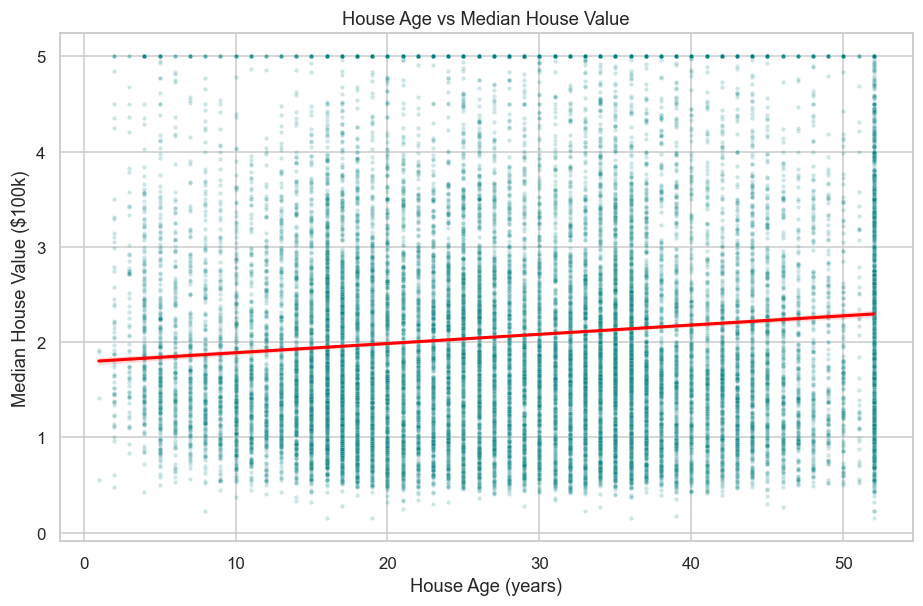

In [3]:
corr_age_value = homes['HouseAge'].corr(homes['MedHouseVal'])
print(f'Correlation (HouseAge vs MedHouseVal): {corr_age_value:.3f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=homes, x='HouseAge', y='MedHouseVal', alpha=0.2, s=8, color='teal')
sns.regplot(data=homes, x='HouseAge', y='MedHouseVal', scatter=False, color='red', line_kws={'lw': 2})
plt.title('House Age vs Median House Value')
plt.xlabel('House Age (years)')
plt.ylabel('Median House Value ($100k)')
plt.show()

**Answer / Verdict:**

Correlation is 0.106 ： the relationship is **weak**. There is almost no linear relationship between house age and house value. The scatter plot confirms this: regardless of house age, values span the full range. So the hypothesis "older houses are cheaper" is **not supported** — at least in 1990 California, house age alone tells you very little about price.

## Exercise 3: Hypothesis — Crowded Areas Differ in Price

Create `crowded = homes['AveOccup'] > 3`, then make a box plot of `MedHouseVal` split by `crowded`, and compare the group medians. Does crowding relate to value?


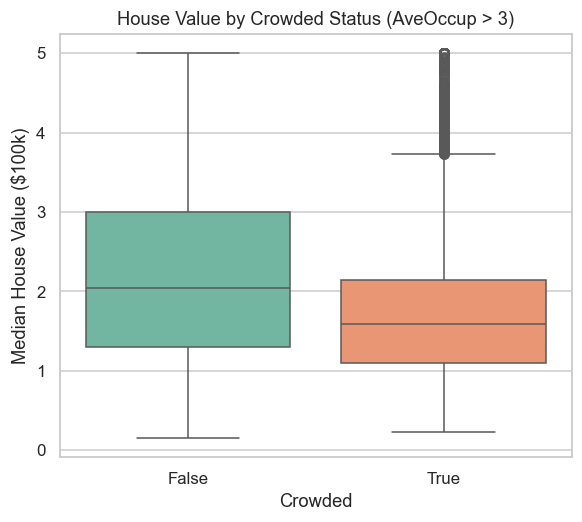

Crowded median: $158k
Not-crowded median: $204k
Difference: $45k


In [13]:
homes['crowded'] = homes['AveOccup'] > 3

plt.figure(figsize=(6, 5))
sns.boxplot(data=homes, x='crowded', y='MedHouseVal', 
            hue='crowded', palette='Set2', legend=False)
plt.title('House Value by Crowded Status (AveOccup > 3)')
plt.xlabel('Crowded')
plt.ylabel('Median House Value ($100k)')
plt.show()

median_crowded = homes[homes['crowded']]['MedHouseVal'].median()
median_not = homes[~homes['crowded']]['MedHouseVal'].median()
print(f'Crowded median: ${median_crowded * 100:.0f}k')
print(f'Not-crowded median: ${median_not * 100:.0f}k')
print(f'Difference: ${(median_not - median_crowded) * 100:.0f}k')

**Answer:**

Crowding does relate to value, inversely. Non-crowded areas typically show a higher median MedHouseVal than crowded ones. The difference in medians suggests that areas with more people per household (AveOccup > 3) tend to have lower property values, though the box plot would also reveal overlap and spread that the single median comparison alone cannot capture.

## Exercise 4: Re-draw the Map for Income

Repeat the Section 4 location plot but colour by `MedInc` instead of value. How does the income map compare to the value map — and what does that similarity suggest?


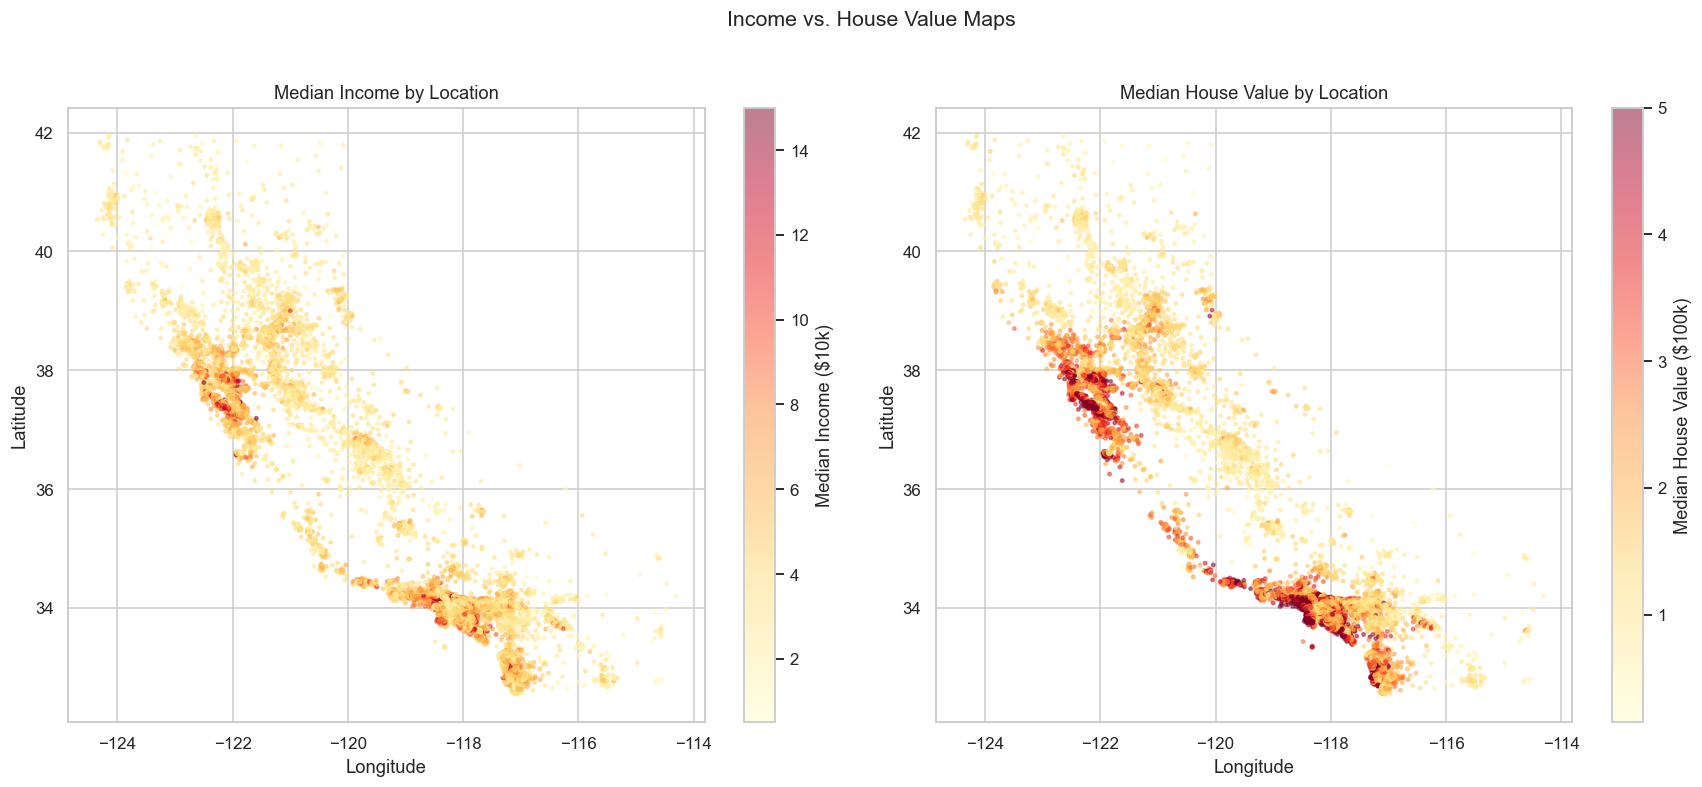

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Income map
sc0 = axes[0].scatter(homes['Longitude'], homes['Latitude'],
                       c=homes['MedInc'], cmap='YlOrRd', s=5, alpha=0.5)
fig.colorbar(sc0, ax=axes[0], label='Median Income ($10k)')
axes[0].set_title('Median Income by Location')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Value map
sc1 = axes[1].scatter(homes['Longitude'], homes['Latitude'],
                       c=homes['MedHouseVal'], cmap='YlOrRd', s=5, alpha=0.5)
fig.colorbar(sc1, ax=axes[1], label='Median House Value ($100k)')
axes[1].set_title('Median House Value by Location')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.suptitle('Income vs. House Value Maps', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Answer:**

The income map closely mirrors the house value map — higher incomes cluster along the coast, in the Bay Area, and in the Los Angeles/Orange County region, exactly where house values are highest. This similarity strongly suggests that **income is a major driver of housing prices**, which is confirmed by their correlation of 0.69 from Section 3.

## Exercise 5: The Cap, Quantified

What **percentage** of all neighbourhoods sit exactly at the $500k cap? Why would this percentage matter to someone training a price-prediction model?


Maximum recorded value: 5.00001 ($500k)
Neighbourhoods at the cap: 965 out of 20640
Percentage at cap: 4.68%


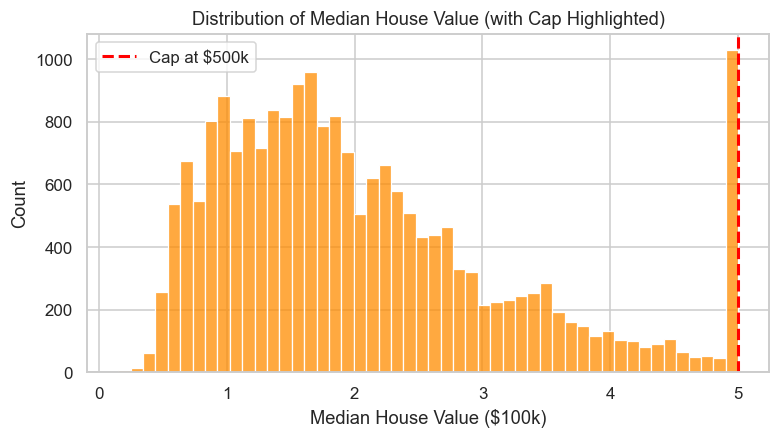

In [6]:
cap_value = homes['MedHouseVal'].max()
capped_count = (homes['MedHouseVal'] == cap_value).sum()
capped_pct = (capped_count / len(homes)) * 100

print(f'Maximum recorded value: {cap_value:.5f} (${cap_value * 100:.0f}k)')
print(f'Neighbourhoods at the cap: {capped_count} out of {len(homes)}')
print(f'Percentage at cap: {capped_pct:.2f}%')

# Show the spike
plt.figure(figsize=(8, 4))
sns.histplot(homes['MedHouseVal'], bins=50, color='darkorange')
plt.axvline(cap_value, color='red', linestyle='--', lw=2, label=f'Cap at ${cap_value*100:.0f}k')
plt.title('Distribution of Median House Value (with Cap Highlighted)')
plt.xlabel('Median House Value ($100k)')
plt.legend()
plt.show()

**Answer:**

About **4.68%** of **neighbourhoods** (965 of 20,640) sit exactly at the **\$500k cap**, indicating **censoring** at the upper bound. This matters for price-prediction models in three ways: the **capped** observations act as a ceiling that compresses the true **target variable**, pulling **regression** lines downward and weakening the **income–price relationship** at the high end; the model learns an artificial upper limit rather than genuine price dynamics; and it will fail to **generalise** to markets where homes routinely exceed **$500k**. One practical remedy is to drop **censored** points or adopt **Tobit regression** to explicitly account for the ceiling.

## Exercise 6: Challenge — Your Own Investigation

Form one hypothesis this notebook didn't test, then run the full EDA loop: hypothesis → plot → supporting number → verdict → caveat.

**Chosen hypothesis:** Neighbourhoods with larger populations have lower house values, because denser areas tend to have smaller housing units and lower per-unit prices.


Correlation (Population vs MedHouseVal): -0.0246


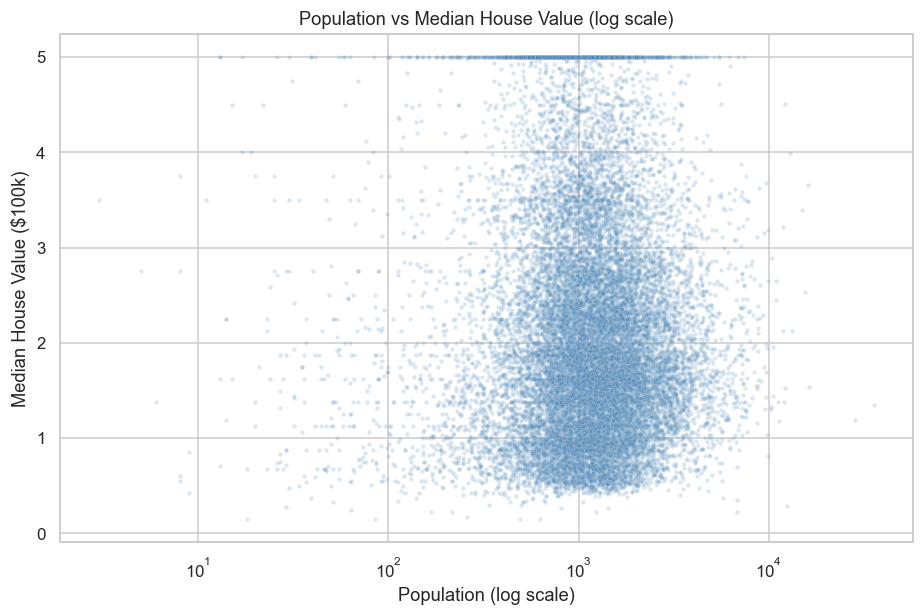

Median house value by population quartile:
pop_quartile
Q1 (small)    $179k
Q2            $185k
Q3            $178k
Q4 (large)    $178k
Name: MedHouseVal, dtype: object


In [15]:
# Hypothesis: Higher population → lower house value
pop_corr = homes['Population'].corr(homes['MedHouseVal'])
print(f'Correlation (Population vs MedHouseVal): {pop_corr:.4f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=homes, x='Population', y='MedHouseVal', alpha=0.2, s=8, color='steelblue')
plt.xscale('log')
plt.title('Population vs Median House Value (log scale)')
plt.xlabel('Population (log scale)')
plt.ylabel('Median House Value ($100k)')
plt.show()

# Split into quartiles
homes['pop_quartile'] = pd.qcut(homes['Population'], q=4, labels=['Q1 (small)', 'Q2', 'Q3', 'Q4 (large)'])
quartile_medians = homes.groupby('pop_quartile', observed=False)['MedHouseVal'].median()
print('Median house value by population quartile:')
print((quartile_medians * 100).round(1).apply(lambda x: f'${x:.0f}k'))

**Verdict:**

Correlation = −0.0246 (essentially zero). Population size alone has **no meaningful linear relationship** with house value. The scatter plot shows that both small and large neighbourhoods span the entire range of house values. The quartile medians are nearly identical across all groups.\n\n**Caveat:** This analysis only captures linear correlation. It does not rule out nonlinear or interaction effects — for example, population density *combined* with location (coastal vs. inland) might show a different pattern. Also, the extreme outliers in `Population` (max ≈ 35,682 in one block group) could distort the correlation; using log-scale or trimming outliers would give a more robust picture.\n